## Given a video, produce a list where each element is the behavior occurring at that frame

In [1]:
import json
import os 
import numpy as np
import math
import matplotlib.pyplot as plt
import cv2

In [2]:
#redirect
os.chdir('/Users/wynnsu/Downloads/DeepLabCut/notebook_h5_csv')

#open and load the JSON file
with open('calms21_task1_train.json', 'r') as file:
    data_train = json.load(file)

with open('calms21_task1_test.json','r') as file:
    data_test = json.load(file)

In [12]:
#convert dictionary to numpy array
np4_classific = np.array(data_train['annotator-id_0']['task1/train/mouse004_task1_annotator1']['annotations'])+1

print(np.shape(np4_classific))

np78_classific = np.array(data_test['annotator-id_0']['task1/test/mouse078_task1_annotator1']['annotations'])+1

assert len(np4_classific) == len(data_train['annotator-id_0']['task1/train/mouse004_task1_annotator1']['annotations'])
#NOTE: my indices are modified - attack: 1, investigation: 2, mount: 3, other: 4

#video 4 - lot of mounting
attack4 = 0
investi4 = 0
mount4 = 0
other4 = 0
for i in np4_classific:
    if i == 1:
        attack4 = attack4 + 1
    elif i == 2:
        investi4 = investi4 + 1
    elif i == 3:
        mount4 = mount4 + 1
    else:
        other4 = other4 + 1

lst4_classific = [attack4,investi4,mount4,other4]

#video 78 - lot of attacks
attack78 = 0
investi78 = 0
mount78 = 0
other78 = 0

for i in np78_classific:
    if i == 1:
        attack78 = attack78 + 1
    elif i == 2:
        investi78 = investi78 + 1
    elif i == 3:
        mount78 = mount78 + 1
    else:
        other78 = other78 + 1

lst78_classific = [attack78,investi78,mount78,other78]

#find whether there was investigation before those behaviors
def pre_mount(np_classific):

    lst_frame = []
    #iterate the array
    for each in range (1,len(np_classific)):
        
    #for every segment of mounting, check if there was an investigation happened before
        if np_classific[each-1] == 2 and np_classific[each] == 3:
            lst_frame.append(each)
    
    #return list of frames where investigation to mount transition
    return np.array(lst_frame)

def pre_attack(np_classific):
    lst_frame = []
    for each in range (1,len(np_classific)):
        if np_classific[each-1] == 2 and np_classific[each] == 1:
            lst_frame.append(each)

    return np.array(lst_frame)
    
print(len(pre_mount(np4_classific)))
print(len(pre_attack(np78_classific)))

mount_gap = pre_mount(np4_classific)
attack_gap = pre_attack(np78_classific)

print((mount_gap[1:] - mount_gap[:-1]))
print((attack_gap[1:] - attack_gap[:-1]))

<class 'dict'>
(7433,)
10
113
[ 449  437  599 1429 1558   79   43  479  249]
[ 165   96   56  188   77   39  966  118  134  163  282   64   89  226
   89   71   82 3141   83   88   46  128   78  213  173  139   96   90
   72   96  121   37   50   58  169  147   25   84   76   96   56   53
   17  316   81   34   93   50   30   71   72   73  399  830  203   24
   12  192   43   86   29  111  172  100   38  106  131  142  124  108
  103  223  241   48   20   40   98   82   38  165  158   40  110   58
   89  229   27   94   34  178  228  219   79   71   69  188 1669   92
  136   34  112  159  165  145  179  118   48  152  147   80  118  111]


<BarContainer object of 4 artists>

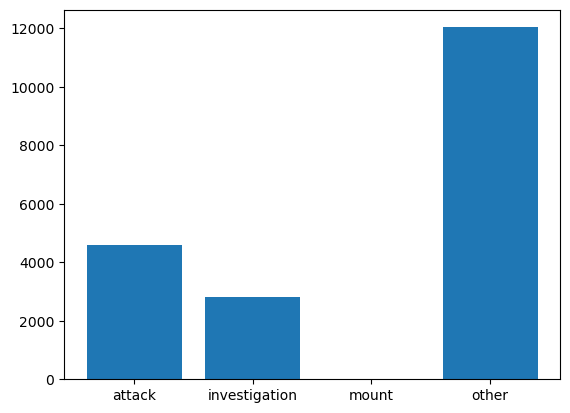

In [4]:
plt.bar(['attack','investigation','mount','other'],lst78_classific)

In [4]:
#extract coordinates

def invert_y(np_coor):
    '''
    inversion of y-coordinates for more intuitive calculations
    '''
    np_coor[:,1,:] = np.abs(np_coor[:,1,:] - 570)
    return np_coor

#data structure [frames,ID,coordinates,part]

np4_coor_resi = invert_y(np.array(data_train['annotator-id_0']['task1/train/mouse004_task1_annotator1']['keypoints'])[:,0,:,:])
np4_coor_intr = invert_y(np.array(data_train['annotator-id_0']['task1/train/mouse004_task1_annotator1']['keypoints'])[:,1,:,:])

np78_coor_resi = invert_y(np.array(data_test['annotator-id_0']['task1/test/mouse078_task1_annotator1']['keypoints'])[:,0,:,:])
np78_coor_intr = invert_y(np.array(data_test['annotator-id_0']['task1/test/mouse078_task1_annotator1']['keypoints'])[:,1,:,:])

In [5]:
#simple features (ex. centroids, neck-to-nose orientation, etc)

def centroid_all(frame,np_coor):
    '''
    input is a mouse xy coordinate for all body parts and a specific frame
    
    calculates centroids based on all body parts

    returns a tuple with 2 elements, indicating centroid's xy coordinate of a single frame
    '''
    centroid_all_x = sum(np_coor[frame,0,:])/len(np_coor[frame,0,:])
    centroid_all_y = sum(np_coor[frame,1,:])/len(np_coor[frame,1,:])

    return (centroid_all_x,centroid_all_y)

def centroid_spec(frame,np_coor):
    '''
    input is a mouse xy coordinate for specific body parts and a specific frame
    
    calculates centroids based on specific body parts

    returns a tuple with 2 elements, indicating the centroid's xy coordinate of a single frame
    '''
    centroid_x = sum(np_coor[:,frame,0])/len(np_coor[:,frame,0])
    centroid_y = sum(np_coor[:,frame,1])/len(np_coor[:,frame,1])

    return (centroid_x,centroid_y)

def dist(point1,point2):
    '''
    calculates the distance between two points
    each point consists of x and y coordinate
    '''
    x = point2[0] - point1[0]
    y = point2[1] - point1[1]
    
    return np.sqrt(x**2 + y**2)

def dot_prod(v1,v2):
    return v1[0]*v2[0] + v1[1]*v2[1]

def angle_btw_lines(resi_nose,resi_neck,intr,add_intr=None):
    """
    three inputs: resident nose & neck & either intruder's centroid or hipL or hipR
    calculates the smallest angle (in degrees) between two lines
    each line is defined by two points: ((x1, y1), (x2, y2))

    four inputs: resident nose & neck AND intruder neck & centroid
    """

    if add_intr is None:
        #line ideal - consists of resi_nose AND intr
        dx1 = intr[0] - resi_nose[0]
        dy1 = intr[1] - resi_nose[1]
        
        #line real - consists of resi_nose AND resi_neck
        dx2 = resi_nose[0] - resi_neck[0]
        dy2 = resi_nose[1] - resi_neck[1]
    
        dot_product = dot_prod([dx1,dy1],[dx2,dy2])
    
        mag_ideal = np.sqrt(dot_prod([dx1,dy1],[dx1,dy1]))
        mag_real = np.sqrt(dot_prod([dx2,dy2],[dx2,dy2]))
        
        cos = dot_product / (mag_ideal*mag_real)
        angle = math.acos(dot_product/(mag_ideal*mag_real))
        angle_degree = math.degrees(angle)
            
        return angle_degree

    else:
        #line intruder
        dx1 = intr[0] - add_intr[0]
        dy1 = intr[1] - add_intr[1]
        
        #line resident
        dx2 = resi_nose[0] - resi_neck[0]
        dy2 = resi_nose[1] - resi_neck[1]
    
        dot_product = dot_prod([dx1,dy1],[dx2,dy2])
    
        mag_intr = np.sqrt(dot_prod([dx1,dy1],[dx1,dy1]))
        mag_resi = np.sqrt(dot_prod([dx2,dy2],[dx2,dy2]))
        
        cos = dot_product / (mag_intr*mag_resi)
        angle = math.acos(dot_product/(mag_intr*mag_resi))
        angle_degree = math.degrees(angle)
            
        return angle_degree

In [6]:
#Display distributions of the kinematic features that occur one second before each of those 3 behaviors
'''
Contact-region-relative-to-target — where the resident's nose/head is oriented on the intruder's body axis (near-hip → predicts attack; near-centroid/T-shape → predicts mount); to be operationalized as a continuous projection, not a discrete zone
Facing angle — resident within a ~±45° cone toward intruder, precedes attack (check redundancy against contact-region before treating as independent)
T-shape / orientation angle (perpendicular configuration) — precedes mount, confirmed as a distinct pre-mount posture with a real intervening repositioning step
Distance to specific target region (not just centroid-to-centroid) — reframing of relative distance around the target-region finding
Time-in-proximity — eyeball inconclusive but not ruled out; flagged as possibly useful for differentiating mount vs. attack, worth testing computationally rather than discarding
S-matrix: to be tested
'''

'''
Hypotheses:
1) near-hip contact predicts escalation to attack
2) near-centroid contact predicts escalation to attack
3) near-head contact predicts escalation to attack or mount
4) near-tail contact predicts escalation to attack or mount
5) increasing sym_ratio over frame predicts escalation to mount
6) NEED TO CHECK HOW SYM_RATIO RELATES TO ATTACK
7) time since last attack OR mount bout predicts escalation to attack or mount
8) longer TRUE visual cone predicts escalation to attack or mount (framed as decision time? not i dont like it)
9) longer FALSE visual cone does not predict escalation to attack or mount
'''

def get_pre_onset(frame_of_interest):
    '''
    for every bout frame, go 30 frames before that bout.
    return a list of 30 frames before a specific frame
    '''

    if frame_of_interest-30 < 0:
        return None
    return np.arange(frame_of_interest-30,frame_of_interest)
    

#contact region relative to intruder - where resident's head is oriented on intruder's body
def contact_region(frame_of_interest,np_coor_resi,np_coor_intr):
    '''
    input a 1D numpy array that indicates when either attack or investigation happened
    checks the T-shape
    returns elements {True_Head,True_Centroid,True_Hip,True_Tail,None}
    '''
    resi_nose = np_coor_resi[frame_of_interest,:,0]
    resi_neck = np_coor_resi[frame_of_interest,:,3]

    intr_centroid_head = centroid_spec(frame_of_interest,np.array([np_coor_intr[:,:,0],np_coor_intr[:,:,1],np_coor_intr[:,:,2],np_coor_intr[:,:,3]]))
    intr_centroid_all = centroid_all(frame_of_interest,np_coor_intr)
    intr_hipL = np_coor_intr[frame_of_interest,:,4]
    intr_hipR = np_coor_intr[frame_of_interest,:,5]
    intr_tail = np_coor_intr[frame_of_interest,:,6]

    #if resident nose is close to intruder head
    if (dist(resi_nose,intr_centroid_head) <= 40 and angle_btw_lines(resi_nose,resi_neck,intr_centroid_head) <= 15):
        return "True_Head"
    
    #elif nose is close to hip AND orientation (from neck to head) is to hip
    elif ((dist(resi_nose,intr_hipL) <= 40 and angle_btw_lines(resi_nose,resi_neck,intr_hipL) <= 15) or 
          (dist(resi_nose,intr_hipR) <= 40 and angle_btw_lines(resi_nose,resi_neck,intr_hipR) <= 15)
         ):
        return "True_Hip"
            
    #elif orientation is close to centroid
    elif dist(resi_nose,intr_centroid_all) <= 40 and angle_btw_lines(resi_nose,resi_neck,intr_centroid_all) <= 15:
        return "True_Centroid"

    #elif orientation is close to tail
    elif (dist(resi_nose,intr_tail) <= 40 and angle_btw_lines(resi_nose,resi_neck,intr_tail) <= 15):
        return "True_Tail"

    #else False
    else:
        return "None"

#s-matrix modified from Khan et al 2025 - quantifies socio-spatial arrangement of body parts (ie head-body-tail interaction relative to other)
'''
S-matrices (symmetry ratio ≈ 0) indicate balanced head-body-tail
(HBT) interaction, e.g., M1 and M2 maintain similar distances between
their heads, bodies, and tails, whereas asymmetric S-matrices (symmetry
ratio ≈ 1) indicate disbalance.
'''
def s_matrix(frame_of_interest,np_coor_resi,np_coor_intr):

    #0: nose-ears-neck centroids (or only nose)
    #1: centroid of all body parts
    #2: tail base
    #construct list of body parts for each mouse

    head_resi = centroid_spec(frame_of_interest,np.array([np_coor_resi[:,:,0],np_coor_resi[:,:,1],np_coor_resi[:,:,2],np_coor_resi[:,:,3]]))
    head_intr = centroid_spec(frame_of_interest,np.array([np_coor_intr[:,:,0],np_coor_intr[:,:,1],np_coor_intr[:,:,2],np_coor_intr[:,:,3]]))
    
    lst_resi = [head_resi,centroid_all(frame_of_interest,np_coor_resi),np_coor_resi[frame_of_interest,:,6]]
    lst_intr = [head_intr,centroid_all(frame_of_interest,np_coor_intr),np_coor_intr[frame_of_interest,:,6]]

    #construct matrix (3x3), where each element represents distance between pair of body parts
    s_m = np.zeros((3,3))
    row,col = np.shape(s_m)

    #iterate rows and columns
    for r in range(row):
        for c in range(col):
            #compute distance between the two body parts in iteration
            d = dist(lst_resi[r],lst_intr[c])
            s_m[r,c] = d

    diff_m = s_m - np.transpose(s_m)

    ori_m_frobenius = np.sqrt(np.sum(np.square(s_m)))
    diff_m_frobenius = np.sqrt(np.sum(np.square(diff_m)))
    
    sym_ratio = diff_m_frobenius/ori_m_frobenius

    return sym_ratio

def facing_angle(frame_of_interest,np_coor_resi,np_coor_intr):
    '''
    returns angle between resident's heading direction & intruder's centroid
    '''
    #coordinates during the frame of interest
    fr_resi_nose = np_coor_resi[frame_of_interest,:,0]
    fr_resi_neck = np_coor_resi[frame_of_interest,:,3]
    fr_intr_neck = np_coor_intr[frame_of_interest,:,3]
    fr_intr_centroid = np_coor_intr[frame_of_interest,:,6]

    #get angle btw resident's heading direction & intruder's centroid
    angle = angle_btw_lines(fr_resi_nose,fr_resi_neck,fr_intr_neck,fr_intr_centroid)

    return angle

def time_since_last_bout(prev_bout,curr_frame):
    '''
    Time-since-last-bout as urgency/noise term

    Hypothesis: time since last bout predicts escalation
    '''
    return curr_frame - prev_bout

def visual_cone(frame_of_interest,np_coor_resi,np_coor_intr): 
    '''
    ±45° cone toward intruder's centroid of head or body
    '''
    #key parts
    intr_centroid_head = centroid_spec(frame_of_interest,np.array([np_coor_intr[:,:,0],np_coor_intr[:,:,1],np_coor_intr[:,:,2],np_coor_intr[:,:,3]]))
    intr_centroid_body = centroid_spec(frame_of_interest,np.array([np_coor_intr[:,:,3],np_coor_intr[:,:,4],np_coor_intr[:,:,5],np_coor_intr[:,:,6]]))
    resi_nose = np_coor_resi[frame_of_interest,:,0]
    resi_neck = np_coor_resi[frame_of_interest,:,3]

    mid_line = resi_nose - resi_neck         #median line of resident
    mid_line_norm = np.linalg.norm(mid_line) #distance

    vec_to_head = intr_centroid_head - resi_nose
    vec_to_body = intr_centroid_body - resi_nose

    #distance from resident's nose to intruder's head & body
    head_dist = np.linalg.norm(vec_to_head)
    body_dist = np.linalg.norm(vec_to_body)
    
    cos_threshold = np.cos(np.radians(45.0))

    #check intruder head
    in_cone_head = False
    if head_dist > 0:
        cos_head = dot_prod(mid_line,vec_to_head) / (mid_line_norm*head_dist)
        if cos_head >= cos_threshold:
            in_cone_head = "True_Head"
            
    #check intruder body
    in_cone_body = False
    if body_dist > 0:
        cos_body = dot_prod(mid_line,vec_to_body) / (mid_line_norm*body_dist)
        if cos_body >= cos_threshold:
            in_cone_body = "True_Body"

    return ([in_cone_head,cos_head],[in_cone_body,cos_body])


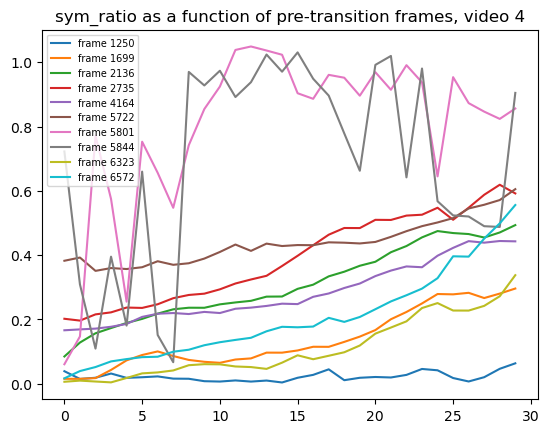

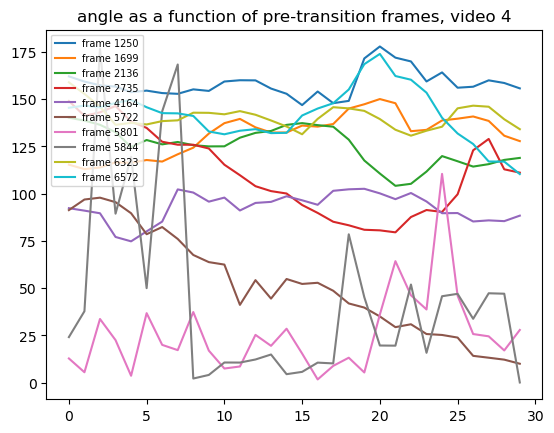

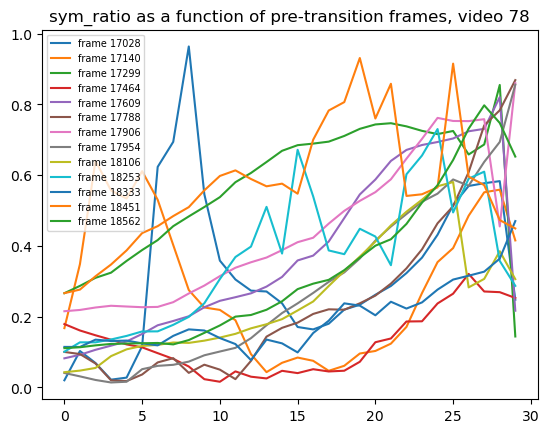

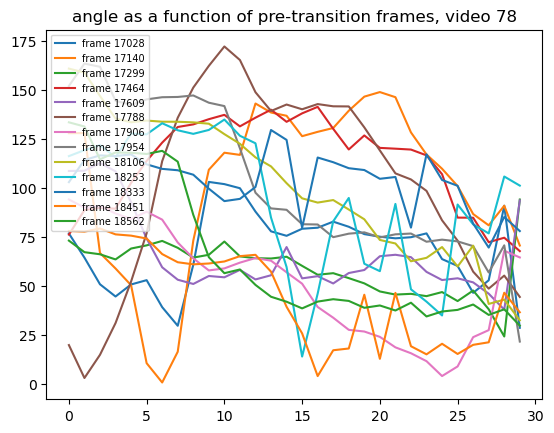

In [7]:
#display distribution for frames

#for each frame in gap, store all 30 frames before the frame in a list -> get_pre_onset ()
lst_frames_vid4 = []
for each in mount_gap:
    frames_vid4 = get_pre_onset(each)
    lst_frames_vid4.append(frames_vid4)


lst_frames_vid78 = []
for each in attack_gap:
    frames_vid78 = get_pre_onset(each)
    lst_frames_vid78.append(frames_vid78)

#for each of those 30 frames, run contact_region(), s_matrix(), facing_angle()
vid4_stats = np.zeros((3,len(lst_frames_vid4),30),dtype=object)
sec_ind = 0
for lst in lst_frames_vid4:
    thi_ind = 0
    for ele in lst:
        c_r = contact_region(ele,np4_coor_resi,np4_coor_intr) #run contact_region()
        s_m = s_matrix(ele,np4_coor_resi,np4_coor_intr)       #run s_matrix()
        f_a = facing_angle(ele,np4_coor_resi,np4_coor_intr)   #run facing_angle()

        vid4_stats[0,sec_ind,thi_ind] = c_r
        vid4_stats[1,sec_ind,thi_ind] = s_m
        vid4_stats[2,sec_ind,thi_ind] = f_a
        
        thi_ind = thi_ind + 1
    sec_ind = sec_ind + 1

vid78_stats = np.empty((3,len(lst_frames_vid78),30),dtype=object) #dimension: derived features x transition frame x frames before transition
sec_ind = 0
for lst in lst_frames_vid78:
    thi_ind = 0
    for ele in lst:
        c_r = contact_region(ele,np78_coor_resi,np78_coor_intr) #run contact_region()
        s_m = s_matrix(ele,np78_coor_resi,np78_coor_intr)       #run s_matrix()
        f_a = facing_angle(ele,np78_coor_resi,np78_coor_intr)   #run facing_angle()

        vid78_stats[0,sec_ind,thi_ind] = c_r
        vid78_stats[1,sec_ind,thi_ind] = s_m
        vid78_stats[2,sec_ind,thi_ind] = f_a
        
        vid78_stats[0,sec_ind,thi_ind]
        thi_ind = thi_ind + 1
    sec_ind = sec_ind + 1

### display distributions across those 30 frames 

#video 4
'''
contact_region() - bar graph
s_matrix() - sym_ratio as a function of time
facing_angle() - angle as a function of time
'''
#contact_region()

x4 = ["True_Hip","True_Centroid","None"]
y4 = None

#s_matrix()
plt.figure(2)
for i in range(len(lst_frames_vid4)): 
    plt.plot(np.arange(0,30),vid4_stats[1,i,:],label=f'frame {mount_gap[i]}')

plt.title("sym_ratio as a function of pre-transition frames, video 4")
plt.legend(fontsize=7,loc='upper left')
plt.show()

#facing_angle()
plt.figure(3)
for i in range(len(lst_frames_vid4)):
    plt.plot(np.arange(0,30),vid4_stats[2,i,:],label=f'frame {mount_gap[i]}')

plt.title("angle as a function of pre-transition frames, video 4")
plt.legend(fontsize=7,loc='upper left')
plt.show()

##########

#video 78

#contact_region()
x4 = ["True_Hip","True_Centroid","None"]
y4 = None

#s_matrix()
plt.figure(5)
for i in range(100,len(lst_frames_vid78)): 
    plt.plot(np.arange(0,30),vid78_stats[1,i,:],label=f'frame {attack_gap[i]}')

plt.title("sym_ratio as a function of pre-transition frames, video 78")
plt.legend(fontsize=7,loc='upper left')
plt.show()

#facing_angle()
plt.figure(6)
for i in range(100,len(lst_frames_vid78)):
    plt.plot(np.arange(0,30),vid78_stats[2,i,:],label=f'frame {attack_gap[i]}')

plt.title("angle as a function of pre-transition frames, video 78")
plt.legend(fontsize=7,loc='upper left')
plt.show()


## Hypotheses
1) near-hip contact predicts escalation to attack
2) near-centroid contact predicts escalation to attack
3) near-head contact predicts escalation to attack or mount
4) near-tail contact predicts escalation to attack or mount
5) increasing sym_ratio (or s_matrix) over frame predicts escalation to mount
6) more dynamic sym_ratio (or s_matrix) over frame predicts escalation to attack
7) time since last attack OR mount bout predicts escalation to attack or mount
9) longer TRUE visual cone predicts escalation to attack or mount
10) longer FALSE visual cone does not predict escalation to attack or mount

## Assumption 
1) Intruder being in ±45° resident's cone initiates accumulation
2) Starting point (z) always begins at 0.5
3) Boundary (a) is constant (ie does not shift)

## Binning

In [8]:
#P(escalation) per bin 
'''
For each bin of your candidate feature (say, inter-mouse distance grouped into 10 bins), 
take all the bout frames whose feature value falls in that bin, and compute the fraction of those bouts that ended in escalation (attack/mount) rather than disengagement. 
You get one probability per bin. Plot bin-center feature value on the x-axis, P(escalation) on the y-axis.

For each bout (attack or mount)
For each candidate feature, group it distinctly into (maybe) 10 bins.
x-axis = frames (time)
y-axis = candidate feature
Find all bouts with the feature, group them into the bins.
Compute fraction of bouts that ended in attack/mount rather than nothing.
Get one probability per pin. 
Plot bin-center feature value on the x-axis. P(escalation) on the y-axis.
'''

def bin_p_contact_region(np_classific,np_coor_resi,np_coor_intr,attack=True):

    #if attack is True, do binning for attack bouts
        #find all frames that contain transition from investigation to attack (pre_attack())
        #for each frame w/ transition, store all 30 frames before the frame in a list -> get_pre_onset ()
        #for each of those 30 frames, run visual_cone()
        #do angle as single scalar feature on x-axis & P(escalation) on y-axis

        #graph
    

    #else, do binning for mount bouts
    
    

###PROBLEM: most of my features are pretty dynamic. not sure if the single scalar vector is a reasonable thing to do for binning...

#mean time-to-escalation per bin 
'''
For each bout (attack & mount), find how long until the bout begins
Put those time into distribution.
Find mean, median, mode.
'''




SyntaxError: unterminated string literal (detected at line 15) (3098652377.py, line 15)

## Debugging Section

In [13]:
### sanity check

#extract specific frames to visually estimate if the current frame behavior matches my function's calculation

cap = cv2.VideoCapture('mouse004_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el_bp_p60_labeled.mp4')
for frame_idx in np.arange(1253-20, 1253+10):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cv2.imwrite(f'frame_{frame_idx}.png', frame)
    
    c_r = contact_region(frame_idx, np4_coor_resi, np4_coor_intr)
    s_m = s_matrix(frame_idx, np4_coor_resi, np4_coor_intr)
    f_a = facing_angle(frame_idx, np4_coor_resi, np4_coor_intr)
    print(f'frame {frame_idx}: contact={c_r}, sym_ratio={s_m:.3f}, facing_angle={f_a:.1f}')

frame 1233: contact=None, sym_ratio=0.010, facing_angle=155.6
frame 1234: contact=None, sym_ratio=0.004, facing_angle=152.8
frame 1235: contact=None, sym_ratio=0.019, facing_angle=146.8
frame 1236: contact=None, sym_ratio=0.028, facing_angle=154.0
frame 1237: contact=None, sym_ratio=0.045, facing_angle=147.9
frame 1238: contact=None, sym_ratio=0.011, facing_angle=149.1
frame 1239: contact=None, sym_ratio=0.019, facing_angle=171.5
frame 1240: contact=None, sym_ratio=0.021, facing_angle=177.8
frame 1241: contact=None, sym_ratio=0.020, facing_angle=171.9
frame 1242: contact=None, sym_ratio=0.028, facing_angle=169.9
frame 1243: contact=None, sym_ratio=0.046, facing_angle=159.3
frame 1244: contact=None, sym_ratio=0.042, facing_angle=164.1
frame 1245: contact=None, sym_ratio=0.018, facing_angle=156.0
frame 1246: contact=None, sym_ratio=0.007, facing_angle=156.6
frame 1247: contact=True_Hip, sym_ratio=0.020, facing_angle=159.9
frame 1248: contact=None, sym_ratio=0.047, facing_angle=158.5
fram

In [11]:
for frame_idx in np.arange(1253-10, 1253+10):
    d_hipL = dist(np4_coor_resi[frame_idx,:,0], np4_coor_intr[frame_idx,:,4]) #distance between resident's nose & intruder's hipL
    d_hipR = dist(np4_coor_resi[frame_idx,:,0], np4_coor_intr[frame_idx,:,5]) 
    d_cent = dist(np4_coor_resi[frame_idx,:,0],centroid_all(frame_idx,np4_coor_intr[:,:,:]))
    
    a_hipL = angle_btw_lines(np4_coor_resi[frame_idx,:,0], np4_coor_resi[frame_idx,:,3], np4_coor_intr[frame_idx,:,4])
    a_hipR = angle_btw_lines(np4_coor_resi[frame_idx,:,0], np4_coor_resi[frame_idx,:,3], np4_coor_intr[frame_idx,:,5])
    a_cent = angle_btw_lines(np4_coor_resi[frame_idx,:,0], np4_coor_resi[frame_idx,:,3], centroid_all(frame_idx,np4_coor_intr[:,:,:]))


    print(f'frame {frame_idx}:')
    print(f'dist_hipL={d_hipL:.1f}, dist_hipR={d_hipR:.1f}, dist_cent={d_cent:.1f}')
    print(f'angle_hipL={a_hipL:.1f}, angle_hipR={a_hipR:.1f}, angle_cent={a_cent:.1f}')
    print(20*"=")


frame 1243:
dist_hipL=99.2, dist_hipR=69.9, dist_cent=51.5
angle_hipL=30.2, angle_hipR=17.1, angle_cent=54.2
frame 1244:
dist_hipL=103.8, dist_hipR=70.1, dist_cent=59.8
angle_hipL=36.8, angle_hipR=5.2, angle_cent=61.3
frame 1245:
dist_hipL=89.1, dist_hipR=54.0, dist_cent=48.1
angle_hipL=31.4, angle_hipR=18.5, angle_cent=65.2
frame 1246:
dist_hipL=80.3, dist_hipR=36.9, dist_cent=50.2
angle_hipL=39.3, angle_hipR=17.3, angle_cent=86.5
frame 1247:
dist_hipL=87.4, dist_hipR=36.6, dist_cent=63.3
angle_hipL=49.9, angle_hipR=6.8, angle_cent=90.6
frame 1248:
dist_hipL=82.7, dist_hipR=15.4, dist_cent=68.6
angle_hipL=61.0, angle_hipR=21.2, angle_cent=103.5
frame 1249:
dist_hipL=78.6, dist_hipR=8.8, dist_cent=70.2
angle_hipL=63.7, angle_hipR=38.7, angle_cent=106.3
frame 1250:
dist_hipL=81.0, dist_hipR=6.7, dist_cent=76.1
angle_hipL=72.5, angle_hipR=67.9, angle_cent=112.1
frame 1251:
dist_hipL=76.2, dist_hipR=8.8, dist_cent=78.3
angle_hipL=67.5, angle_hipR=121.1, angle_cent=108.5
frame 1252:
dist_h

In [12]:
c_r = contact_region(1259, np4_coor_resi, np4_coor_intr)
f_a = facing_angle(1259, np4_coor_resi, np4_coor_intr)

print(f_a)

True_Centroid


In [13]:
print(visual_cone(1100,np4_coor_resi,np4_coor_intr))

(['True_Head', np.float64(0.738347285478673)], [False, np.float64(0.5580040166120319)])
